In [1]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score
)
import matplotlib.pyplot as plt
import shap

/home/vvk/python/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('../data/diabetes_prediction_dataset.csv')
numeric = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
categorial = ['gender', 'hypertension', 'heart_disease', 'smoking_history']
multi_category= ["gender", "smoking_history"]
RANDOM_STATE = 42
TARGET_COL = "diabetes"

Разделим все данные на train и test. Подбор методов обработки признаков, настройку гиперпараметров и оценку качества будем проводить только на кросс-валидации на train. Test служит для финальной оценки качества лучшей модели.

In [3]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)


In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Основной метрикой качества выбрана Recall, поскольку в задаче прогнозирования диабета критически важно минимизировать количество ложноотрицательных классификаций (False Negative), то есть не пропустить пациентов, действительно имеющих заболевание. При этом дополнительно анализируются метрики Precision, F1-score и ROC-AUC для комплексной оценки качества модели.

## 1. Logistic Regression

In [ ]:
processor = ColumnTransformer(
        transformers=[
            ("category", OneHotEncoder(drop='first'), multi_category),
            ("numeric", StandardScaler(), numeric),
        ],
        remainder="passthrough",
        verbose_feature_names_out=False
    )

logistic_reg = Pipeline([
    ("preprocess", processor),
    ("logreg", LogisticRegression(
        random_state=RANDOM_STATE))
])

param_grid = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logreg__l1_ratio': [0, 0.5, 1],
    'logreg__solver': ['liblinear', 'saga'],
    'logreg__class_weight': [None, 'balanced'],
    'logreg__max_iter': [1000]
}

gs_lg = GridSearchCV(
    estimator=logistic_reg,
    param_grid=param_grid,
    scoring='recall',
    cv=skf,
    n_jobs=-1
    )

gs_lg.fit(X_train, y_train)
print("Логистическая регрессия:")
print("Лучшие параметры:", gs_lg.best_params_)
print("Лучший recall на кросс-валидации:", gs_lg.best_score_)

/home/vvk/python/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/vvk/python/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/vvk/python/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/vvk/python/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/vvk/python/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/vvk/python/venv/lib/python3.12/site-packages/sklearn/linear_mode

In [12]:
y_pred_lg = cross_val_predict(
    gs_lg.best_estimator_,
    X_train, y_train,
    cv=skf,
    n_jobs=-1
)

print("Отчёт по классам (модель logistic regression):")
print(classification_report(y_train, y_pred_lg))

Отчёт по классам (модель logistic regression):
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     73200
           1       0.37      0.90      0.53      6800

    accuracy                           0.86     80000
   macro avg       0.68      0.88      0.72     80000
weighted avg       0.94      0.86      0.89     80000



## 2. Decision Tree

In [13]:
processor = ColumnTransformer(
        transformers=[
            ("category", OrdinalEncoder(), multi_category)
        ],
        remainder="passthrough",
        verbose_feature_names_out=False
    )

decision_tree = Pipeline([
    ("preprocess", processor),
    ("dectree", DecisionTreeClassifier(
        random_state=RANDOM_STATE))
])

param_grid = {
    'dectree__max_depth': [3, 5, 7, None],
    'dectree__min_samples_split': [2, 5, 10, 15],
    'dectree__min_samples_leaf': [5, 10, 15, 20],
    'dectree__criterion': ['gini', 'entropy'],
    'dectree__class_weight': [None, 'balanced']
}

gs_dt= GridSearchCV(
    decision_tree,
    param_grid=param_grid,
    cv=skf,
    scoring="recall",
    n_jobs=-1
)

gs_dt.fit(X_train, y_train)
print("Дерево решений:")
print("Лучшие параметры:", gs_dt.best_params_)
print("Лучший recall на кросс-валидации:", gs_dt.best_score_)

Дерево решений:
Лучшие параметры: {'dectree__class_weight': 'balanced', 'dectree__criterion': 'entropy', 'dectree__max_depth': 5, 'dectree__min_samples_leaf': 5, 'dectree__min_samples_split': 2}
Лучший recall на кросс-валидации: 0.9675


In [14]:
y_pred_dt = cross_val_predict(
    gs_dt.best_estimator_,
    X_train, y_train,
    cv=skf,
    n_jobs=-1
)

print("Отчёт по классам (модель decision tree):")
print(classification_report(y_train, y_pred_dt))

Отчёт по классам (модель decision tree):
              precision    recall  f1-score   support

           0       1.00      0.80      0.88     73200
           1       0.31      0.97      0.46      6800

    accuracy                           0.81     80000
   macro avg       0.65      0.88      0.67     80000
weighted avg       0.94      0.81      0.85     80000



Модель дерева решений достигла высокой полноты (Recall = 0.97) для класса пациентов с диабетом, что означает обнаружение 97% всех заболевших и минимальное количество ложноотрицательных прогнозов. Однако значение Precision = 0.31 свидетельствует о большом числе ложноположительных классификаций: значительная часть пациентов, отнесённых моделью к группе риска, фактически не имеет диабета. Следовательно, модель хорошо подходит для задач первичного скрининга, где приоритетом является минимизация пропуска больных.

## 3. Random Forest

In [5]:
processor = ColumnTransformer(
        transformers=[
            ("category", OrdinalEncoder(), multi_category)
        ],
        remainder="passthrough",
        verbose_feature_names_out=False
    )

random_forest = Pipeline([
    ("preprocess", processor),
    ("ranforest", RandomForestClassifier(
        random_state=RANDOM_STATE, n_jobs=-1))
])

param_grid = {
    'ranforest__n_estimators': [50, 100],
    'ranforest__max_depth': [None, 10, 20],
    'ranforest__min_samples_split': [2, 5],
    'ranforest__min_samples_leaf': [1, 2],
    'ranforest__max_features': ['sqrt', 'log2'],
    'ranforest__bootstrap': [True, False],
    'ranforest__class_weight': ['balanced'],
    'ranforest__criterion': ['gini', 'entropy']

}

gs_rf= GridSearchCV(
    random_forest,
    param_grid=param_grid,
    cv=skf,
    scoring="recall",
    n_jobs=-1
)

gs_rf.fit(X_train, y_train)
print("Случайный лес:")
print("Лучшие параметры:", gs_rf.best_params_)
print("Лучший recall на кросс-валидации:", gs_rf.best_score_)

Случайный лес:
Лучшие параметры: {'ranforest__bootstrap': False, 'ranforest__class_weight': 'balanced', 'ranforest__criterion': 'gini', 'ranforest__max_depth': 10, 'ranforest__max_features': 'log2', 'ranforest__min_samples_leaf': 1, 'ranforest__min_samples_split': 2, 'ranforest__n_estimators': 100}
Лучший recall на кросс-валидации: 0.9173529411764706


In [6]:
y_pred_rf = cross_val_predict(
    gs_rf.best_estimator_,
    X_train, y_train,
    cv=skf,
    n_jobs=-1
)

print("Отчёт по классам (модель random forest):")
print(classification_report(y_train, y_pred_rf))

Отчёт по классам (модель random forest):
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     73200
           1       0.45      0.92      0.61      6800

    accuracy                           0.90     80000
   macro avg       0.72      0.91      0.77     80000
weighted avg       0.95      0.90      0.91     80000



## 4. XGBoost

In [32]:
xgboost = Pipeline([
    ('preprocessor', processor),
    ('xgb', XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        tree_method='hist'
    ))
])

param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0],
    'xgb__min_child_weight': [1, 5],
    'xgb__gamma': [0, 0.1],
    'xgb__scale_pos_weight': [1, 10]
}

gs_xgb= GridSearchCV(
    estimator=xgboost,
    param_grid=param_grid,
    scoring='recall',
    cv=skf,
    n_jobs=-1,
    verbose=2
)

gs_xgb.fit(X_train, y_train)

print("Лучшие параметры:", gs_xgb.best_params_)
print("Лучший recall:", gs_xgb.best_score_)

Fitting 5 folds for each of 576 candidates, totalling 2880 fits
[CV] END xgb__colsample_bytree=0.8, xgb__gamma=0, xgb__learning_rate=0.01, xgb__max_depth=3, xgb__min_child_weight=1, xgb__n_estimators=100, xgb__scale_pos_weight=1, xgb__subsample=0.8; total time=   0.9s
[CV] END xgb__colsample_bytree=0.8, xgb__gamma=0, xgb__learning_rate=0.01, xgb__max_depth=3, xgb__min_child_weight=1, xgb__n_estimators=100, xgb__scale_pos_weight=1, xgb__subsample=1.0; total time=   0.9s
[CV] END xgb__colsample_bytree=0.8, xgb__gamma=0, xgb__learning_rate=0.01, xgb__max_depth=3, xgb__min_child_weight=1, xgb__n_estimators=100, xgb__scale_pos_weight=1, xgb__subsample=0.8; total time=   1.0s
[CV] END xgb__colsample_bytree=0.8, xgb__gamma=0, xgb__learning_rate=0.01, xgb__max_depth=3, xgb__min_child_weight=1, xgb__n_estimators=100, xgb__scale_pos_weight=1, xgb__subsample=0.8; total time=   1.1s
[CV] END xgb__colsample_bytree=0.8, xgb__gamma=0, xgb__learning_rate=0.01, xgb__max_depth=3, xgb__min_child_weight=1

In [33]:
y_pred_xgb = cross_val_predict(
    gs_xgb.best_estimator_,
    X_train, y_train,
    cv=skf,
    n_jobs=-1
)

print("Отчёт по классам (модель xgboost):")
print(classification_report(y_train, y_pred_xgb))

Отчёт по классам (модель xgboost):
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     73200
           1       0.39      0.94      0.55      6800

    accuracy                           0.87     80000
   macro avg       0.69      0.90      0.73     80000
weighted avg       0.94      0.87      0.89     80000



Удалось достигнуть большего recall по сравнению с Random Forest, но при этом снижен precision.

# Сравнение моделей на тесте

In [34]:
best_lr = gs_lg.best_estimator_
best_dt = gs_dt.best_estimator_
best_rf = gs_rf.best_estimator_
best_xgb = gs_xgb.best_estimator_

In [35]:
models = [best_lr, best_dt, best_rf, best_xgb]
name_models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

for idx, model in enumerate(models):
    print(name_models[idx])
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    print('Accuracy:', accuracy_score(y_test, y_pred))
    print('Precision:', precision_score(y_test, y_pred))
    print('Recall:', recall_score(y_test, y_pred))
    print('F1-score:', f1_score(y_test, y_pred))
    print('ROC-AUC-score', roc_auc_score(y_test, y_proba))
    print()

Logistic Regression
Accuracy: 0.8676
Precision: 0.3827313211281544
Recall: 0.91
F1-score: 0.5388366422849181
ROC-AUC-score 0.9611587753134041

Decision Tree
Accuracy: 0.8025
Precision: 0.2981700753498385
Recall: 0.9776470588235294
F1-score: 0.45697003024470717
ROC-AUC-score 0.9606503696560591

Random Forest
Accuracy: 0.8984
Precision: 0.4517722254503196
Recall: 0.9147058823529411
F1-score: 0.6048230260598989
ROC-AUC-score 0.9767556734169078

XGBoost
Accuracy: 0.8677
Precision: 0.3858039594398841
Recall: 0.94
F1-score: 0.547072920232797
ROC-AUC-score 0.9751710221793636



| Модель | Accuracy | Precision | Recall | F1-score | ROC-AUC-score |
|--------|----------|-----------|--------|----------|---------------|
| Logistic Regression | 0.8676 | 0.3827 | 0.91 | 0.5388 | 0.9611 |
| Decision Tree | 0.8025 | 0.2981 | 0.9776 | 0.4569 | 0.9606 |
| Random Forest | 0.8984 | 0.4517 | 0.9147 | 0.6048 | 0.9767 |
| XGBoost | 0.8677 | 0.3858 | 0.94 | 0.5471 | 0.9751 |

- Лучшей по Recall показала себя модель Дерева решений, что типично для неё, так как она была оптимизирвоана по метрике Recall. При этом точность самая низкая у этой модели, значит модель упускает около 70% пациентов, которые здоровы, а модель признала их больными. Отсюда следует, что F1-score также самый низкий.
- Случайный лес показывает лучшие показатели по всем метрикам, за исключением Recall. Значение Recall сопоставимо со значением baseline-модели Логистической регрессии. Также случайный лес лучше всех разделеят классы. 
- XGBoost имеет средние значения Recall и F1-score среди всех моделей и в целом уступает случайному лесу. 
Таким образом, итоговой моделью определим Random Forest, которая может быть использована для прогнозирования риска развитися диабета.  

## Feature Importance

In [8]:
rf = best_rf.named_steps['ranforest']
feature_names = best_rf.named_steps['preprocess'].get_feature_names_out()

importance = rf.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

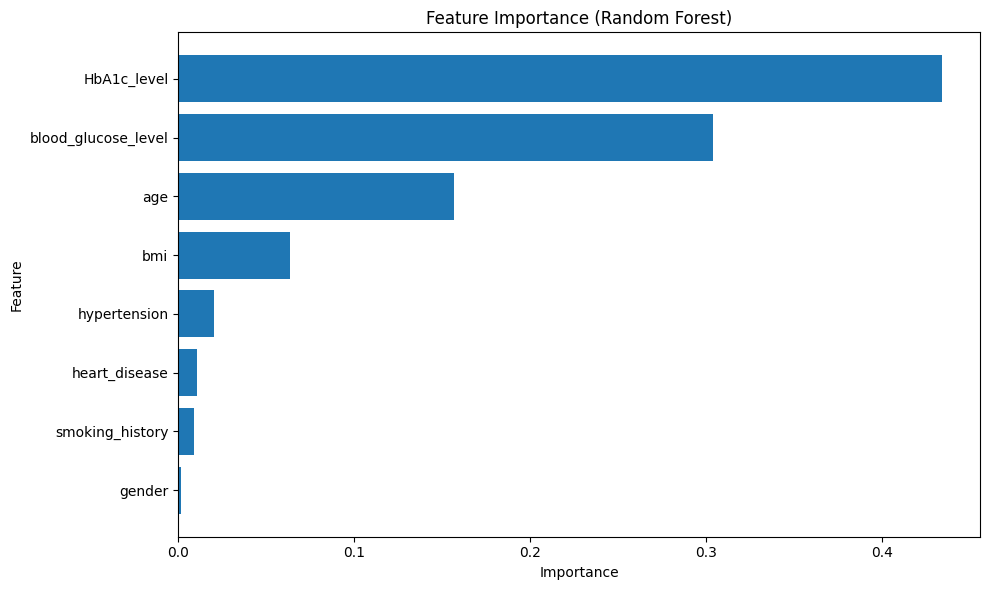

In [9]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance (Random Forest)')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

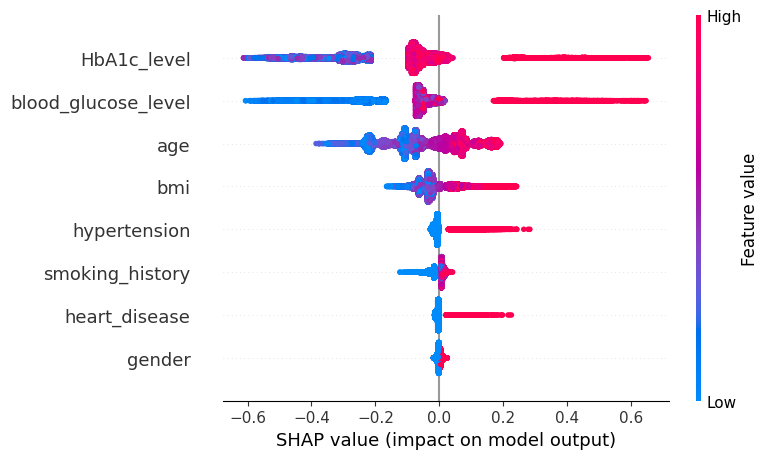

<Figure size 640x480 with 0 Axes>

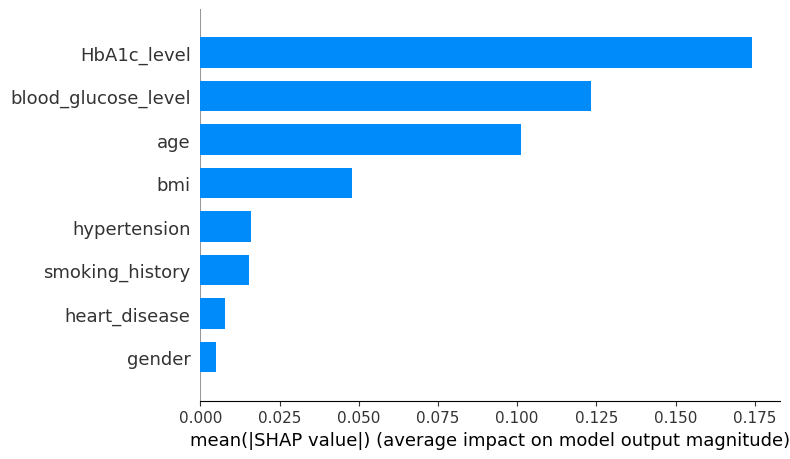

In [25]:
preprocessor = ColumnTransformer(
        transformers=[
            ("category", OrdinalEncoder(), multi_category)
        ],
        remainder="passthrough",
        verbose_feature_names_out=False
    )

best_pipeline = gs_rf.best_estimator_
best_pipeline.set_params(**gs_rf.best_params_)
best_pipeline.fit(X_train, y_train)
best_model = best_pipeline.named_steps['ranforest']

preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
X_train_df = pd.DataFrame(X_train_transformed, columns=preprocessor.get_feature_names_out())

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train_df)
shap_values_positive = shap_values[:, :, 1]

shap.initjs()
shap.summary_plot(shap_values_positive, X_train_df)

plt.tight_layout()
plt.show()

shap.summary_plot(shap_values_positive, X_train_df, plot_type="bar", show=False)

Как и предполагалась на этапе анализа признаков, признаки уровень глюкозы и гликированный гемоглобин (HbA1c) имеют наибольшую важность, то есть модель в основном чаще всего их использует при принятии решения.
Анализ SHAP-значений показывает, что повышенные значения HbA1c и уровня глюкозы увеличивает вероятность диабета. Возраст и bmi имееют менее выраженную зависимость, но влияние также присутствует. Наличие гипертония и заболевания сердца с высокой вероятностью приводит к заболеваниям сердца. 

In [31]:
y_pred = best_rf.predict(X_test)
print("Отчёт по классам (модель Random Forest):")
print(classification_report(y_test, y_pred))

Отчёт по классам (модель Random Forest):
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     18300
           1       0.45      0.91      0.60      1700

    accuracy                           0.90     20000
   macro avg       0.72      0.91      0.77     20000
weighted avg       0.95      0.90      0.91     20000

